<a href="https://colab.research.google.com/github/Fares-pr0g/ML-journey-ep-3-Experimenting-with-Transformers-and-Intro-to-LLM-s/blob/main/Project%203%3A%20Intro_to_GAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Vanilla Generative Adversial Networks to generate synthethic MNIST like data

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np


In [2]:
# Device Agnostic Code
device= 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [3]:
# Let's create generalized functions to create the two constructing model-blocks:

# The Generator

def make_generator_network(input_size= 20, num_hidden_layers=1,
                           num_hidden_units=100, num_output_units= 784):

  model=nn.Sequential()

  for i in range (num_hidden_layers):
    model.add_module(f'fc_g{i}', nn.Linear(input_size, num_hidden_units))
    model.add_module(f'relu_g', nn.LeakyReLU())
    input_size=num_hidden_units
  model.add_module(f'fc_g{i+1}', nn.Linear(input_size, num_output_units))
  model.add_module(f'tanh_g', nn.Tanh())
  return model

# The Discriminator

def make_discriminator_network(input_size, num_hidden_layers=1,
                               num_hidden_units=100, num_output_units=1):
  model=nn.Sequential()

  for i in range (num_hidden_layers):
    model.add_module(f'fc_d{i}', nn.Linear(input_size, num_hidden_units, bias= False))
    model.add_module(f'relu_d', nn.LeakyReLU())
    model.add_module('dropout', nn.Dropout(p=0.5))
    input_size=num_hidden_units
  model.add_module(f'fc_d{i+1}', nn.Linear(input_size, num_output_units))
  model.add_module(f'sigmoid_d', nn.Sigmoid())
  return model


In [4]:
# Initializing the networks & their params to our problem

image_size= (28,28)
z_size=20

torch.manual_seed(42)

generator_model= make_generator_network(num_output_units= np.prod(image_size))
print(generator_model)

discriminator_model= make_discriminator_network(input_size= np.prod(image_size))
print(discriminator_model)


Sequential(
  (fc_g0): Linear(in_features=20, out_features=100, bias=True)
  (relu_g): LeakyReLU(negative_slope=0.01)
  (fc_g1): Linear(in_features=100, out_features=784, bias=True)
  (tanh_g): Tanh()
)
Sequential(
  (fc_d0): Linear(in_features=784, out_features=100, bias=False)
  (relu_d): LeakyReLU(negative_slope=0.01)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc_d1): Linear(in_features=100, out_features=1, bias=True)
  (sigmoid_d): Sigmoid()
)


## Setting the training Dataset

In [5]:
import torchvision
from torchvision import transforms

image_transform= transforms.Compose([
   transforms.ToTensor(),
   transforms.Normalize(mean=(0.5), std=(0.5)), # output = (input - mean) / std
   ])
mnist_dataset= torchvision.datasets.MNIST(
    root='./data', train=True,
    download=True, transform=image_transform
)


the min value is: -1.0, the max value is: 1.0


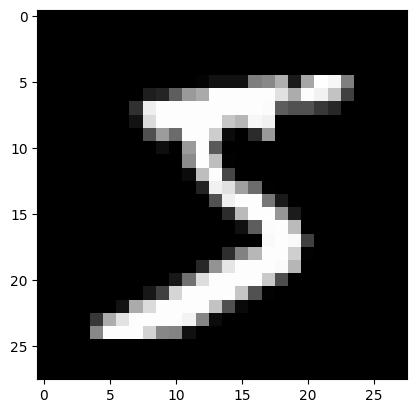

In [6]:
# Let's test if the values are between -1 & 1 to match the tanh outputs in the last layer in the Generator

example, sample= mnist_dataset[0]


example= example.squeeze().numpy()
example.shape

print( f'the min value is: {example.min()}, the max value is: {example.max()}')
plt.imshow(example, cmap='gray', vmin= -1, vmax= 1)

In [7]:
# Now Let's create the Z vector to feed the generator

def create_noise(batch_size, z_size, mode):

  if mode =='uniform':
    input_z= torch.rand(batch_size, z_size)*2 - 1
  else:
    input_z=torch.randn(batch_size, z_size)
    if mode != 'normal': print('Mode not recognized, the "normal" mode was used')

  return input_z


**The Feedforward Process:**

z -> gen -> g_output\
g_output -> discrim -> fake_proba\
real_sample -> disc -> real_proba

In [8]:
from torch.utils.data import DataLoader

BATCH_SIZE= 32
dataloader= DataLoader(mnist_dataset, BATCH_SIZE, shuffle= False)

input_real, label= next(iter(dataloader))
input_real= input_real.view(BATCH_SIZE, -1)  #makes the shape goes from (B,1,28,28) to (B,728)

torch.manual_seed(42)
input_z= create_noise(BATCH_SIZE, z_size, mode='normal')

print('input-z -- shape:', input_z.shape)
print('input-real -- shape:', input_real.shape)

g_output= generator_model(input_z)

print('Output of G -- shape:', g_output.shape)

d_proba_real= discriminator_model(input_real)
d_proba_fake= discriminator_model(g_output)

print('Disc. (real) -- shape:', d_proba_real.shape)
print('Disc. (fake) -- shape:', d_proba_fake.shape)

input-z -- shape: torch.Size([32, 20])
input-real -- shape: torch.Size([32, 784])
Output of G -- shape: torch.Size([32, 784])
Disc. (real) -- shape: torch.Size([32, 1])
Disc. (fake) -- shape: torch.Size([32, 1])


# Training the GAN model

| Loss | Label for `d_proba_fake` | Interpretation |
|---|---|---|
| `d_loss_fake` (training D) | 0 | "Fake images should be classified as fake" |
| `g_loss` (training G) | 1 | "G wants D to be tricked into saying fake images are real" |

In [9]:
# Let's set everything to the device first

generator_model= generator_model.to(device)
discriminator_model= discriminator_model.to(device)

# Let's set the optimizer and the loss funct (we will use the BCE for replicating the same loss funct used in the initial paper)

loss_fn=nn.BCELoss()
g_optimizer= torch.optim.Adam(generator_model.parameters())
d_optimizer= torch.optim.Adam(discriminator_model.parameters())

# Let's create the train dataloader
mnist_dl = DataLoader(mnist_dataset, BATCH_SIZE, shuffle= True, drop_last= True)



In [10]:
# Train the discriminator
mode_z= 'uniform'

def d_train(x):
  discriminator_model.zero_grad()

  # Train discriminator with a real batch

  x= x.view(BATCH_SIZE, -1).to(device)

  # Apply label smoothing for real labels only (one-sided smoothing)
  d_labels_real= torch.full((BATCH_SIZE, 1), 0.9, device=device) # Smoothed label for real images
  d_proba_real= discriminator_model(x)
  d_loss_real= loss_fn(d_proba_real, d_labels_real)

  # Train discriminator on a fake batch

  z= create_noise(BATCH_SIZE, z_size, mode_z).to(device)
  g_output= generator_model(z)

  d_labels_fake= torch.zeros(BATCH_SIZE, 1, device=device)
  d_proba_fake= discriminator_model(g_output)
  d_loss_fake= loss_fn(d_proba_fake, d_labels_fake)

  # gradient backpropagation on the sum of the losses and optimize only D's params
  d_loss= d_loss_real + d_loss_fake
  d_loss.backward()
  d_optimizer.step()
  return d_loss.item(), d_proba_real.detach(), d_proba_fake.detach()
  # check why detach is important for removing the computational graph if you forget

  # Train the generator

def g_train(x):

  '''The subtility here is that we want the generator to get close to outputting real images
  so the label that we will backprop on should be the correct aka ones vector and we want
  d_proba_fake to get cllose to that, opposite to the discriminator model'''

  generator_model.zero_grad()
  z= create_noise(BATCH_SIZE, z_size, mode_z).to(device)
  g_output= generator_model(z)
  g_labels_real= torch.ones(BATCH_SIZE, 1, device= device)


  g_proba_fake= discriminator_model(g_output)
  g_loss= loss_fn(g_proba_fake, g_labels_real)
  g_loss.backward()
  g_optimizer.step()
  return g_loss.item()

In [11]:
# Let's train the models for some epochs (here we'll chose 100 epochs) and create some samples

from timeit import default_timer as timer

start_time=timer()

fixed_z= create_noise(BATCH_SIZE, z_size, mode=mode_z).to(device)

def create_sample(g_model, input_z):

  g_output= g_model(input_z)
  g_output= torch.reshape(g_output, (BATCH_SIZE, 28, 28))
  return (g_output+1)/2.0

epoch_samples= []
all_d_losses=  []
all_g_losses=  []
all_d_real= []
all_d_fake= []
num_epochs= 100

for epoch in range(1, num_epochs+1):
  d_losses, g_losses= [], []
  d_vals_real, d_vals_fake= [], []
  for i, (x, _) in enumerate(mnist_dl):
    d_loss, d_proba_real, d_proba_fake= d_train(x)
    d_losses.append(d_loss)
    g_losses.append(g_train(x))
    d_vals_real.append(d_proba_real.mean().cpu())
    d_vals_fake.append(d_proba_fake.mean().cpu())

  all_d_losses.append(torch.tensor(d_losses).mean())
  all_g_losses.append(torch.tensor(g_losses).mean())
  all_d_real.append(torch.tensor(d_vals_real).mean())
  all_d_fake.append(torch.tensor(d_vals_fake).mean())

  # The Logging
  print(f'Epoch {epoch:03d} | Avg Losses >>'
        f' G/D {all_g_losses[-1]:.4f}/{all_d_losses[-1]:.4f}'
        f' [D-Real: {all_d_real[-1]:.4f}'
        f' D-Fake: {all_d_fake[-1]:.4f}]')
  print(f'time taken so far: {(timer() - start_time):.3f}')

  # create current samples
  epoch_samples.append(create_sample(generator_model, fixed_z).detach().cpu().numpy())

Epoch 001 | Avg Losses >> G/D 0.9922/1.0660 [D-Real: 0.6832 D-Fake: 0.4086]
time taken so far: 23.008
Epoch 002 | Avg Losses >> G/D 1.0126/1.2439 [D-Real: 0.5188 D-Fake: 0.3878]
time taken so far: 45.694
Epoch 003 | Avg Losses >> G/D 1.0538/1.2516 [D-Real: 0.5167 D-Fake: 0.3816]
time taken so far: 68.391
Epoch 004 | Avg Losses >> G/D 0.9948/1.2681 [D-Real: 0.5095 D-Fake: 0.3920]
time taken so far: 91.186
Epoch 005 | Avg Losses >> G/D 1.1043/1.2184 [D-Real: 0.5328 D-Fake: 0.3694]
time taken so far: 114.630
Epoch 006 | Avg Losses >> G/D 1.0877/1.2168 [D-Real: 0.5361 D-Fake: 0.3688]
time taken so far: 136.667
Epoch 007 | Avg Losses >> G/D 1.0762/1.2249 [D-Real: 0.5304 D-Fake: 0.3716]
time taken so far: 159.292
Epoch 008 | Avg Losses >> G/D 1.0167/1.2658 [D-Real: 0.5111 D-Fake: 0.3898]
time taken so far: 182.188
Epoch 009 | Avg Losses >> G/D 1.0155/1.2634 [D-Real: 0.5112 D-Fake: 0.3888]
time taken so far: 205.179
Epoch 010 | Avg Losses >> G/D 1.0133/1.2653 [D-Real: 0.5101 D-Fake: 0.3898]
t

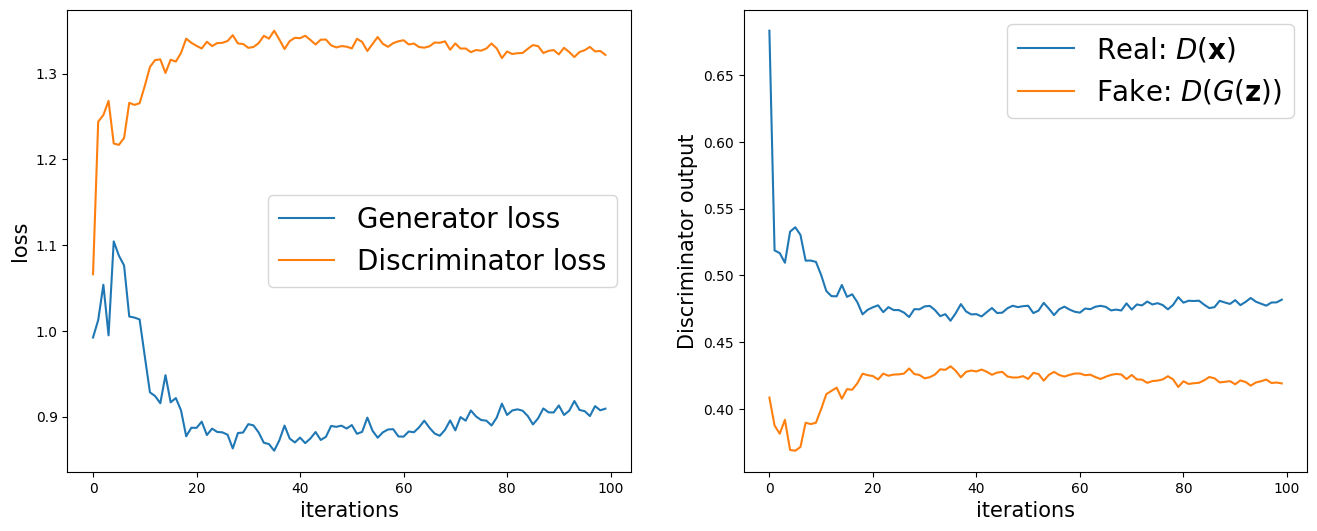

In [12]:
# Let's visualize the learning curves (losses and probabilities) of both subnetworks

fig= plt.figure(figsize=(16,6))

# 1. plotting the losses

ax= fig.add_subplot(1,2,1)
plt.plot(all_g_losses, label='Generator loss')
plt.plot(all_d_losses, label='Discriminator loss')
plt.legend(fontsize=20)
ax.set_xlabel('iterations', size=15)
ax.set_ylabel('loss', size=15)

# 2. plotting the probabilities

ax= fig.add_subplot(1,2,2)
plt.plot(all_d_real, label=r'Real: $D(\mathbf{x})$')
plt.plot(all_d_fake, label=r'Fake: $D(G(\mathbf{z}))$')
plt.legend(fontsize=20)
ax.set_xlabel('iterations', size=15)
ax.set_ylabel('Discriminator output', size=15)

plt.show()

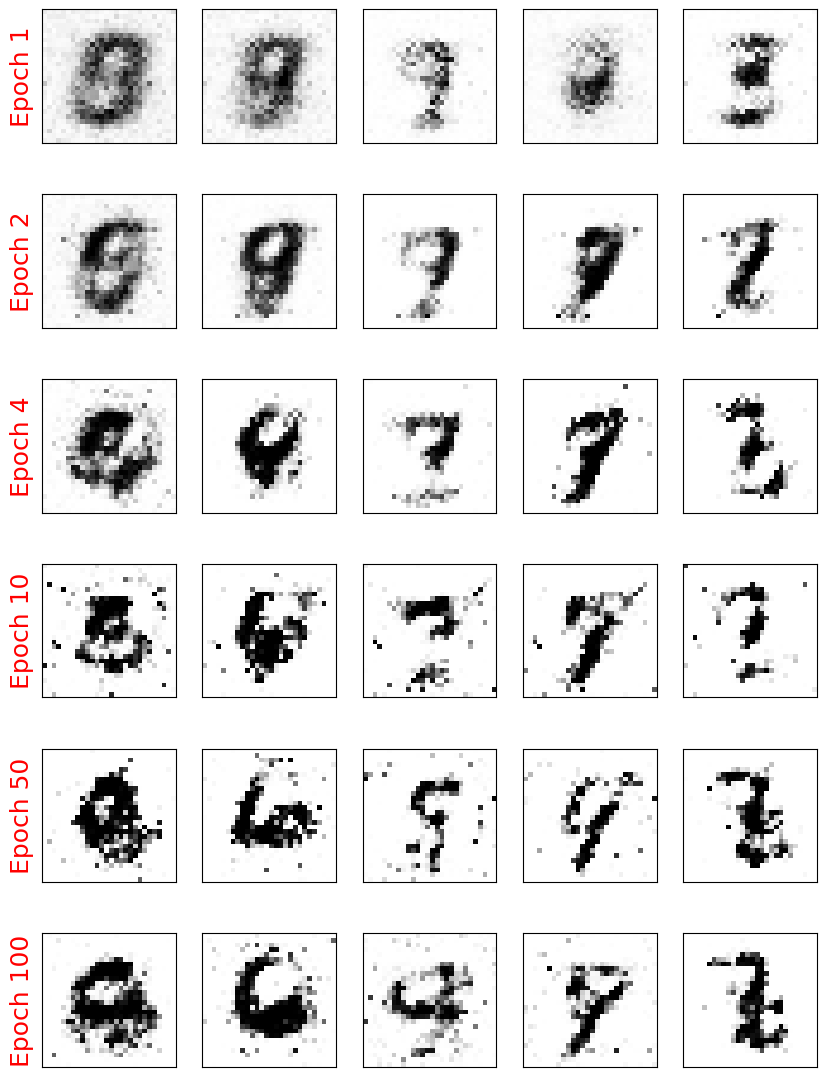

In [13]:
# Let's have a concreate sense of the generator's work through training
# We will output some samples of the synthetic images

selected_epochs = [1, 2, 4, 10, 50, 100]
fig = plt.figure(figsize=(10, 14))
for i,e in enumerate(selected_epochs):
  for j in range(5):
    ax = fig.add_subplot(6, 5, i*5+j+1)
    ax.set_xticks([])
    ax.set_yticks([])
    if j == 0:
      ax.text(
          -0.06, 0.5, f'Epoch {e}',
          rotation=90, size=18, color='red',
          horizontalalignment='right',
          verticalalignment='center',
          transform=ax.transAxes)

    image = epoch_samples[e-1][j]
    ax.imshow(image, cmap='gray_r')

plt.show()